In [1]:
import ssnake as ss

ModuleNotFoundError: No module named 'ssnake'

## Using nmr glue

In [2]:
import nmrglue as ng
import numpy as np
import matplotlib.pyplot as plt
import os


Optimization terminated successfully.
         Current function value: 9820997774.464708
         Iterations: 128
         Function evaluations: 244
Optimization terminated successfully.
         Current function value: 684586958.139569
         Iterations: 128
         Function evaluations: 248
Optimization terminated successfully.
         Current function value: 9167037721.724155
         Iterations: 125
         Function evaluations: 239
Optimization terminated successfully.
         Current function value: 1025956438.400033
         Iterations: 130
         Function evaluations: 250
Optimization terminated successfully.
         Current function value: 9223142497.780067
         Iterations: 126
         Function evaluations: 244
Optimization terminated successfully.
         Current function value: 1056831678.327674
         Iterations: 141
         Function evaluations: 266
Optimization terminated successfully.
         Current function value: 9639955741.793015
         Iteration

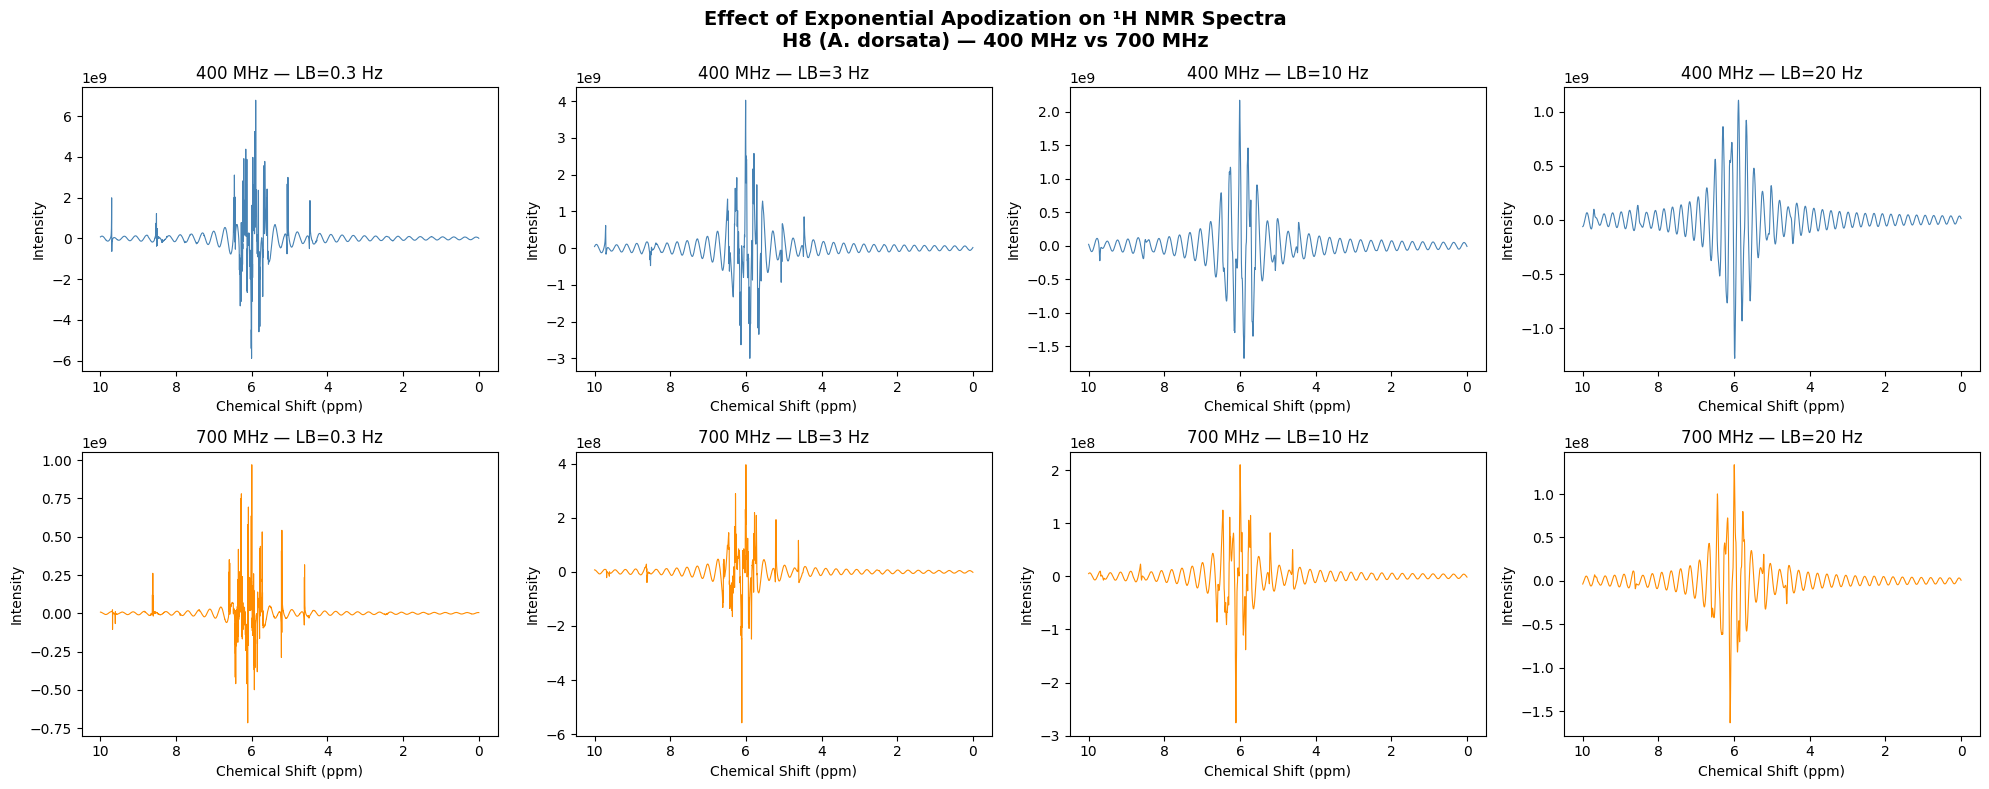

Done — saved as apodization_comparison.png


In [4]:

SAMPLES_400 = ["H1","H2","H3","H4","H5","H6","H7","H8",
                "H9","H10","H11","H12","H13","H14","H15",
                "H16","H17","H18","H19","H20"]

SAMPLES_700 = [s.replace("H","C") for s in SAMPLES_400]

LB_VALUES = [0.3, 3, 10, 20]

def process_fid(path, lb_hz):
    dic, fid = ng.bruker.read(path)
    sw_hz = dic["acqus"]["SW_h"]
    dw = 1.0 / sw_hz
    t = np.arange(len(fid)) * dw
    em = np.exp(-np.pi * lb_hz * t)
    fid_lb = fid * em
    zf = int(2 ** np.ceil(np.log2(len(fid_lb) * 2)))
    fid_zf = ng.proc_base.zf_size(fid_lb, zf)
    spec = ng.proc_base.fft(fid_zf)
    spec = ng.proc_autophase.autops(spec, "acme")
    udic = ng.bruker.guess_udic(dic, fid)
    udic[0]["size"] = len(spec)
    uc = ng.fileiobase.uc_from_udic(udic)
    ppm = uc.ppm_scale()
    return ppm, np.real(spec)

# Plot all LB values for one representative sample per class
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, lb in enumerate(LB_VALUES):
    # 400 MHz — H8 (honey bee representative)
    path_400 = f"data/400MHz/H8/10"
    ppm, spec = process_fid(path_400, lb)
    mask = (ppm > 0) & (ppm < 10)
    axes[0, col].plot(ppm[mask], spec[mask], 
                      linewidth=0.8, color='steelblue')
    axes[0, col].set_title(f"400 MHz — LB={lb} Hz")
    axes[0, col].set_xlabel("Chemical Shift (ppm)")
    axes[0, col].invert_xaxis()
    axes[0, col].set_ylabel("Intensity")

    # 700 MHz — C8 (honey bee representative)
    path_700 = f"data/700MHz/C8"
    ppm, spec = process_fid(path_700, lb)
    mask = (ppm > 0) & (ppm < 10)
    axes[1, col].plot(ppm[mask], spec[mask],
                      linewidth=0.8, color='darkorange')
    axes[1, col].set_title(f"700 MHz — LB={lb} Hz")
    axes[1, col].set_xlabel("Chemical Shift (ppm)")
    axes[1, col].invert_xaxis()
    axes[1, col].set_ylabel("Intensity")

plt.suptitle("Effect of Exponential Apodization on ¹H NMR Spectra\n"
             "H8 (A. dorsata) — 400 MHz vs 700 MHz",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("apodization_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done — saved as apodization_comparison.png")

LB = Line BroadeningIt is the parameter that controls how much you artificially broaden the NMR peaks.


LB = 0.3 Hz → original sharp peaks, high resolution, expensive instrument quality
LB = 3 Hz → slightly broader peaks, still good resolution
LB = 10 Hz → noticeably broader, cheaper instrument quality
LB = 20 Hz → very broad peaks, poor resolution

Optimization terminated successfully.
         Current function value: 9820997774.464708
         Iterations: 128
         Function evaluations: 244
Optimization terminated successfully.
         Current function value: 9167037721.724155
         Iterations: 125
         Function evaluations: 239
Optimization terminated successfully.
         Current function value: 9223142497.780067
         Iterations: 126
         Function evaluations: 244
Optimization terminated successfully.
         Current function value: 9639955741.793015
         Iterations: 142
         Function evaluations: 275
Optimization terminated successfully.
         Current function value: 10258919438.591303
         Iterations: 102
         Function evaluations: 195
Optimization terminated successfully.
         Current function value: 11884562268.530584
         Iterations: 112
         Function evaluations: 216
Optimization terminated successfully.
         Current function value: 9684564779.974722
         Iterat

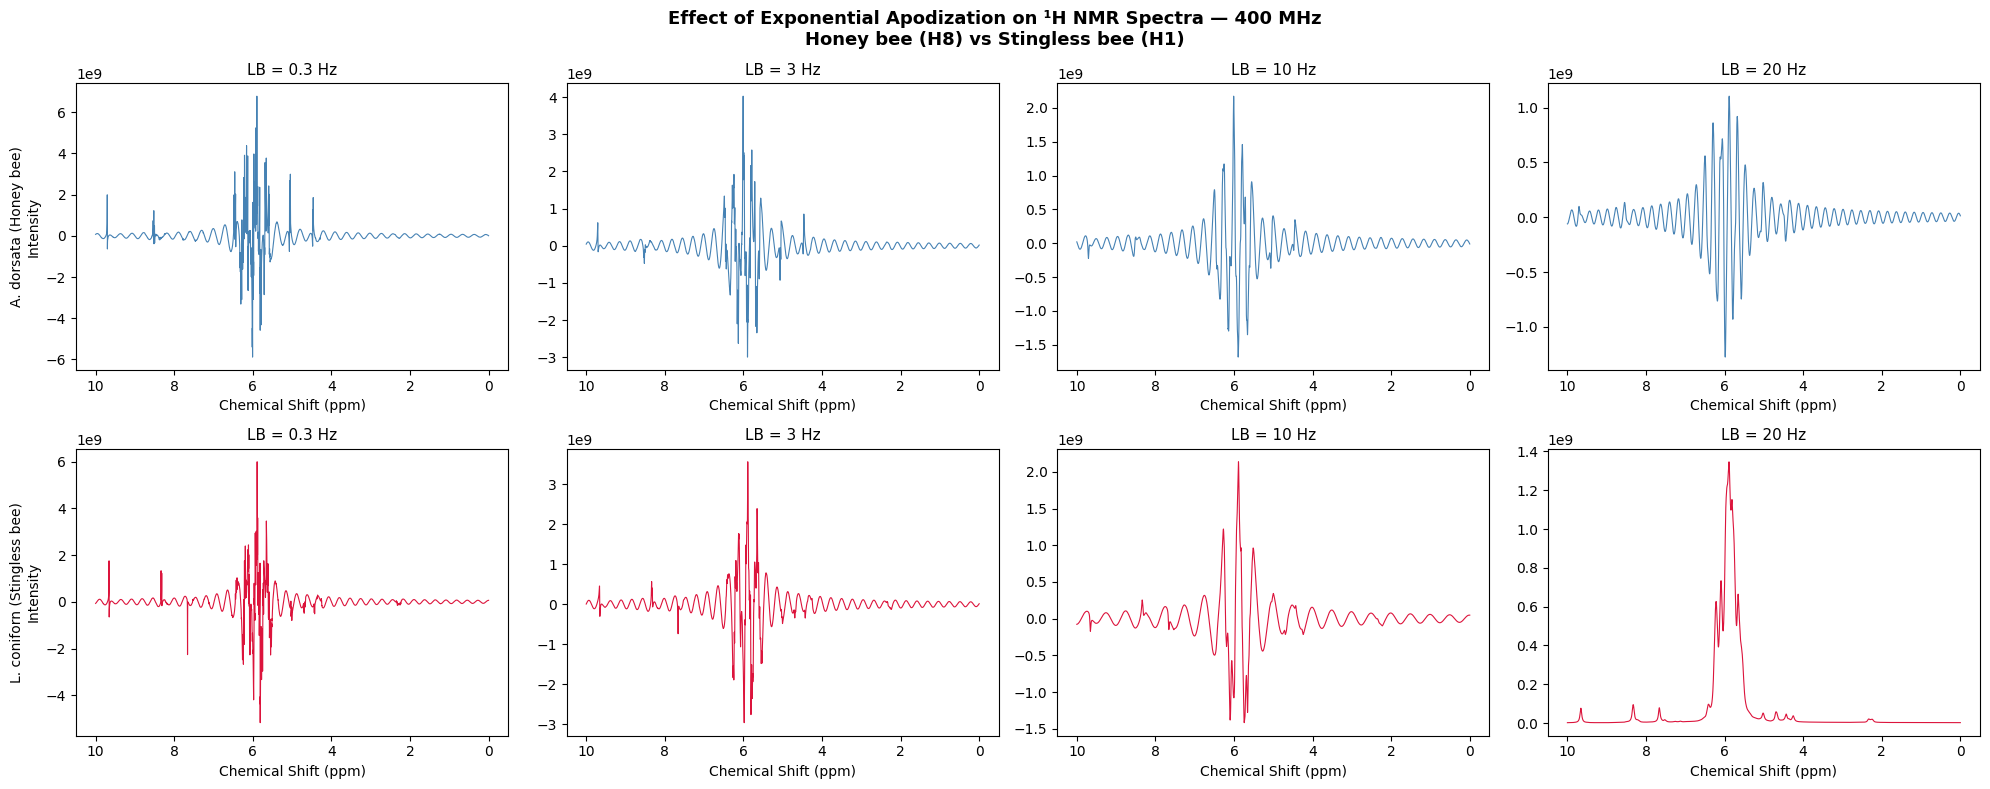

Done


In [5]:
# import nmrglue as ng
# import numpy as np
# import matplotlib.pyplot as plt
LB_VALUES = [0.3, 3, 10, 20]

def process_fid(path, lb_hz):
    dic, fid = ng.bruker.read(path)
    sw_hz = dic["acqus"]["SW_h"]
    dw = 1.0 / sw_hz
    t = np.arange(len(fid)) * dw
    em = np.exp(-np.pi * lb_hz * t)
    fid_lb = fid * em
    zf = int(2 ** np.ceil(np.log2(len(fid_lb) * 2)))
    fid_zf = ng.proc_base.zf_size(fid_lb, zf)
    spec = ng.proc_base.fft(fid_zf)
    spec = ng.proc_autophase.autops(spec, "acme")
    udic = ng.bruker.guess_udic(dic, fid)
    udic[0]["size"] = len(spec)
    uc = ng.fileiobase.uc_from_udic(udic)
    ppm = uc.ppm_scale()
    return ppm, np.real(spec)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

samples = [
    ("H8", "data/400MHz/H8/10", "A. dorsata (Honey bee)", "steelblue"),
    ("H1", "data/400MHz/H1/10", "L. coniforn (Stingless bee)", "crimson"),
]

for row, (code, path, label, color) in enumerate(samples):
    for col, lb in enumerate(LB_VALUES):
        ppm, spec = process_fid(path, lb)
        mask = (ppm > 0) & (ppm < 10)
        axes[row, col].plot(ppm[mask], spec[mask],
                           linewidth=0.8, color=color)
        axes[row, col].set_title(f"LB = {lb} Hz", fontsize=11)
        axes[row, col].invert_xaxis()
        axes[row, col].set_xlabel("Chemical Shift (ppm)")
        if col == 0:
            axes[row, col].set_ylabel(f"{label}\nIntensity")

plt.suptitle("Effect of Exponential Apodization on ¹H NMR Spectra — 400 MHz\n"
             "Honey bee (H8) vs Stingless bee (H1)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("apodization_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done")